# Transformer Architecture

**Build a multi-head self-attention mechanism from scratch and compare against a bag-of-words baseline on real spam detection data.**

Learn how the Transformer's core innovation -- self-attention -- lets a model weigh the importance of every word against every other word. You will implement single-head attention from scratch in NumPy, use it for SMS spam classification, and compare against sklearn's TF-IDF + LogisticRegression baseline to see why word order matters.

**Prerequisites:** Linear algebra, basic calculus, Python, NumPy, familiarity with softmax and cross-entropy.

**Kaggle Dataset:** [SMS Spam Collection](https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset)
*Credit: UCI Machine Learning Repository -- SMS Spam Collection v.1.*
*Download via kagglehub (`pip install kagglehub`) or from the Kaggle link above.*


In [1]:
import numpy as np                # Numerical computing -- build attention from scratch
import pandas as pd               # Data loading and manipulation
import matplotlib.pyplot as plt   # Plotting
import seaborn as sns             # Statistical visualizations
import os                         # File path handling
import re                         # Regular expressions for text cleaning
from collections import Counter   # Vocabulary building
from sklearn.model_selection import train_test_split  # Train/test split
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer  # Text features for sklearn baseline
from sklearn.linear_model import LogisticRegression   # Sklearn baseline classifier
from sklearn.pipeline import Pipeline                 # Sklearn pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix  # Evaluation

try:
    import kagglehub
    KAGGLEHUB_AVAILABLE = True
except ImportError:
    KAGGLEHUB_AVAILABLE = False
    print('kagglehub not installed. Run: pip install kagglehub')

np.random.seed(42)


## Part 1: Theory Recap

**Transformer architecture in five key equations:**

1. **Scaled dot-product attention:**  
   $\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$  
   Every token compares itself to every other token via dot products; scaling prevents softmax saturation.

2. **Multi-head attention:**  
   $\text{MHA}(X) = \text{Concat}(\text{head}_1, \dots, \text{head}_h)W^O,\quad \text{head}_i = \text{Attention}(XW_i^Q, XW_i^K, XW_i^V)$  
   Multiple attention operations run in parallel; each head learns a different relationship type.

3. **Positional encoding (sinusoidal):**  
   $\text{PE}_{(pos,2i)} = \sin(pos / 10000^{2i/d})$,  
   $\text{PE}_{(pos,2i+1)} = \cos(pos / 10000^{2i/d})$  
   Sine/cosine waves at different frequencies let the model infer relative positions.

4. **Feed-forward network:**  
   $\text{FFN}(x) = W_2 \cdot \text{GELU}(W_1 x + b_1) + b_2$  
   Expands each token to higher dimension then projects back.

5. **Cross-entropy loss (classification):**  
   $\mathcal{L} = -\frac{1}{N}\sum_{i=1}^N \log\left(\frac{e^{\text{logits}_{i,y_i}}}{\sum_j e^{\text{logits}_{i,j}}}\right)$  
   Measures how well the predicted class distribution matches the true labels.


## Dataset: SMS Spam Collection

A collection of 5,574 SMS messages labeled as **ham** (legitimate) or **spam**.
This is a classic binary text classification dataset.

| Column | Description |
|--------|-------------|
| `v1` | Label: 'ham' or 'spam' |
| `v2` | Raw SMS message text |

**Our approach:** Train a simplified Transformer encoder that uses self-attention to weigh word importance. Messages with patterns like 'FREE' or 'WINNER' in certain contexts should trigger spam detection. We compare against a bag-of-words baseline to show that word order (captured by attention) matters.


In [2]:
# --- Load dataset -------------------------------------------------
if KAGGLEHUB_AVAILABLE:
    path = kagglehub.dataset_download('uciml/sms-spam-collection-dataset')
    df = pd.read_csv(os.path.join(path, 'spam.csv'), encoding='latin-1')
else:
    df = pd.read_csv('spam.csv', encoding='latin-1')

# Keep only the two useful columns; drop unnamed extras
df = df[['v1', 'v2']].rename(columns={'v1': 'label', 'v2': 'message'})

print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'\nLabel distribution:')
print(df['label'].value_counts().to_string())
print(f'\nSpam ratio: {(df["label"]=="spam").mean()*100:.2f}%')
print()
df.head()


100%|██████████| 211k/211k [00:00<00:00, 15.0MB/s]

Extracting files...
Shape: 5,572 rows x 2 columns

Label distribution:


label
ham     4825
spam     747

Spam ratio: 13.41%



,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
print('Dataset info:')
df.info()
print('\nMessage length statistics (words):')
msg_lengths = df['message'].str.split().str.len()
print(msg_lengths.describe())


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB

Message length statistics (words):
count    5572.000000
mean       15.494436
std        11.329427
min         1.000000
25%         7.000000
50%        12.000000
75%        23.000000
max       171.000000
Name: message, dtype: float64


In [4]:
# --- Encode labels: ham=0, spam=1 --------------------------------
df['label_code'] = (df['label'] == 'spam').astype(int)
print(f'Null values: {df.isnull().sum().sum()}')

# --- Clean text: lowercase, remove non-alphanumeric, collapse spaces
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    return re.sub(r'\s+', ' ', text).strip()

df['clean'] = df['message'].apply(clean_text)

# --- Build vocabulary (most common 2000 words) ------------------
all_words = []
for msg in df['clean']:
    all_words.extend(msg.split())
word_counts = Counter(all_words)
vocab = {word: idx + 1 for idx, (word, _) in enumerate(word_counts.most_common(1999))}
vocab['<PAD>'] = 0
vocab['<UNK>'] = len(vocab)  # 2001
VOCAB_SIZE = len(vocab)
print(f'Vocabulary size: {VOCAB_SIZE}')

# --- Tokenize and pad sequences to max_len = 20 -----------------
MAX_LEN = 20
def tokenize(msg):
    tokens = [vocab.get(w, vocab['<UNK>']) for w in msg.split()]
    # Truncate or pad
    if len(tokens) >= MAX_LEN:
        return tokens[:MAX_LEN]
    else:
        return tokens + [0] * (MAX_LEN - len(tokens))

X = np.array([tokenize(msg) for msg in df['clean']], dtype=np.int32)
y = df['label_code'].values

# --- Train/test split (stratified) ------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f'\nTrain: {X_train.shape}, Test: {X_test.shape}')
print(f'Train spam ratio: {y_train.mean()*100:.1f}%')
print(f'Test spam ratio:  {y_test.mean()*100:.1f}%')


Null values: 0
Vocabulary size: 2001

Train: (3900, 20), Test: (1672, 20)
Train spam ratio: 13.4%
Test spam ratio:  13.4%


## Part 2: From Scratch Implementation (NumPy)

We build a **simplified single-layer Transformer encoder** for text classification.
While the full Transformer has many layers, multi-head attention, and layer norm, our version keeps the core -- **self-attention with positional encoding** -- and adds a classification head on top.

**Architecture:**
1. Token embedding lookup (random init) + sinusoidal positional encoding
2. Single-head self-attention ($Q$, $K$, $V$ projections + scaled dot-product)
3. Mean pooling over the sequence dimension
4. Linear classifier (project pooled vector to 2 classes)

**Interview Note:** The attention mechanism is the heart of the Transformer. Understanding its forward and backward pass -- especially the softmax backprop through $Q$ and $K$ -- is a common FAANG interview question.


In [5]:
class SimpleTransformer:
    """
    Simplified single-head Transformer encoder for sequence classification.

    Components: embedding + positional encoding + self-attention + classifier.
    Trained with mini-batch SGD on cross-entropy loss.
    """
    def __init__(self, vocab_size, embed_dim, max_len, num_classes, lr=0.01):
        self.embed_dim = embed_dim
        self.max_len = max_len
        self.lr = lr
        self.loss_history = []

        # Token embedding matrix
        # Interview Note: Xavier/Glorot init prevents vanishing gradients early on
        self.embed = np.random.randn(vocab_size, embed_dim) * np.sqrt(2.0 / vocab_size)

        # Sinusoidal positional encoding (fixed, no learned params)
        self.pos_enc = self._build_pos_encoding(max_len, embed_dim)

        # Self-attention projections (single head): Q, K, V, Output
        limit = np.sqrt(6.0 / embed_dim)
        self.W_q = np.random.uniform(-limit, limit, (embed_dim, embed_dim))
        self.W_k = np.random.uniform(-limit, limit, (embed_dim, embed_dim))
        self.W_v = np.random.uniform(-limit, limit, (embed_dim, embed_dim))
        self.W_o = np.random.uniform(-limit, limit, (embed_dim, embed_dim))

        # Classification head
        self.W_cls = np.random.randn(embed_dim, num_classes) * 0.01
        self.b_cls = np.zeros(num_classes)

    def _build_pos_encoding(self, max_len, d):
        pe = np.zeros((max_len, d))
        for pos in range(max_len):
            for i in range(0, d, 2):
                freq = 10000 ** (2.0 * i / d)
                pe[pos, i] = np.sin(pos / freq)
                if i + 1 < d:
                    pe[pos, i + 1] = np.cos(pos / freq)
        return pe  # [max_len, d]

    def _softmax(self, x, axis=-1):
        x_max = np.max(x, axis=axis, keepdims=True)
        exp_x = np.exp(x - x_max)  # subtract max for numerical stability
        return exp_x / np.sum(exp_x, axis=axis, keepdims=True)

    def forward(self, X):
        """Forward pass: returns logits and cache for backward."""
        N, T = X.shape
        # 1. Embedding + positional encoding
        emb = self.embed[X]                    # [N, T, d]
        emb = emb + self.pos_enc[:T]           # add pos encoding (broadcast)

        # 2. Self-attention: Q, K, V projections
        Q = emb @ self.W_q                     # [N, T, d]
        K = emb @ self.W_k                     # [N, T, d]
        V = emb @ self.W_v                     # [N, T, d]

        # 3. Scaled dot-product attention
        scores = (Q @ K.transpose(0, 2, 1)) / np.sqrt(self.embed_dim)  # [N, T, T]
        attn = self._softmax(scores, axis=-1)  # attention weights
        context = attn @ V                      # [N, T, d]
        out = context @ self.W_o               # [N, T, d]

        # 4. Mean pooling over sequence
        pooled = np.mean(out, axis=1)           # [N, d]

        # 5. Classification
        logits = pooled @ self.W_cls + self.b_cls  # [N, num_classes]

        cache = (emb, Q, K, V, scores, attn, context, out, pooled)
        return logits, cache

    def backward(self, X, y, logits, cache):
        """Backward pass: compute gradients and update weights."""
        N = X.shape[0]
        emb, Q, K, V, scores, attn, context, out, pooled = cache

        # Cross-entropy gradient: d_logits = softmax - one_hot
        softmax_out = self._softmax(logits)
        d_logits = softmax_out.copy()
        d_logits[np.arange(N), y] -= 1
        d_logits /= N

        # --- Classifier gradients ---
        d_W_cls = pooled.T @ d_logits
        d_b_cls = np.sum(d_logits, axis=0)
        d_pooled = d_logits @ self.W_cls.T            # [N, d]

        # --- Mean pooling gradient (un-pool: distribute evenly) ---
        d_out = np.tile(d_pooled[:, np.newaxis, :], (1, self.max_len, 1)) / self.max_len

        # --- Output projection ---
        d_context = d_out @ self.W_o.T
        d_W_o = context.transpose(0, 2, 1) @ d_out
        d_W_o = np.sum(d_W_o, axis=0)

        # --- Attention backward ---
        # d_attn: gradient w.r.t. attention weights
        d_attn = d_context @ V.transpose(0, 2, 1)    # [N, T, T]
        d_V = attn.transpose(0, 2, 1) @ d_context    # [N, T, d]

        # Softmax backward: d_scores = attn * (d_attn - sum(d_attn * attn))
        d_scores = attn * (d_attn - np.sum(d_attn * attn, axis=-1, keepdims=True))
        d_scores /= np.sqrt(self.embed_dim)           # undo scaling

        # Scores = Q @ K^T / sqrt(d)
        d_Q = d_scores @ K                            # [N, T, d]
        d_K = d_scores.transpose(0, 2, 1) @ Q         # [N, T, d]

        # --- Projection gradients ---
        d_W_q = emb.transpose(0, 2, 1) @ d_Q
        d_W_k = emb.transpose(0, 2, 1) @ d_K
        d_W_v = emb.transpose(0, 2, 1) @ d_V
        d_W_q = np.sum(d_W_q, axis=0)
        d_W_k = np.sum(d_W_k, axis=0)
        d_W_v = np.sum(d_W_v, axis=0)

        # --- Embedding backward (accumulate gradients at each token index) ---
        d_emb = (d_Q @ self.W_q.T + d_K @ self.W_k.T + d_V @ self.W_v.T)
        d_embed = np.zeros_like(self.embed)
        for n in range(N):
            for t in range(self.max_len):
                idx = X[n, t]
                if idx != 0:  # skip padding
                    d_embed[idx] += d_emb[n, t]

        # --- SGD weight updates ---
        self.W_q -= self.lr * d_W_q
        self.W_k -= self.lr * d_W_k
        self.W_v -= self.lr * d_W_v
        self.W_o -= self.lr * d_W_o
        self.W_cls -= self.lr * d_W_cls
        self.b_cls -= self.lr * d_b_cls
        self.embed -= self.lr * d_embed

    def fit(self, X, y, batch_size=64, epochs=30, verbose=True):
        """Train with mini-batch SGD."""
        n = X.shape[0]
        for epoch in range(1, epochs + 1):
            indices = np.random.permutation(n)
            epoch_loss = 0.0
            for start in range(0, n, batch_size):
                end = min(start + batch_size, n)
                batch_X = X[indices[start:end]]
                batch_y = y[indices[start:end]]

                logits, cache = self.forward(batch_X)
                loss = -np.mean(np.log(self._softmax(logits)[np.arange(len(batch_y)), batch_y] + 1e-8))
                epoch_loss += loss * len(batch_y)
                self.backward(batch_X, batch_y, logits, cache)

            avg_loss = epoch_loss / n
            self.loss_history.append(avg_loss)
            if verbose and epoch % 5 == 0:
                train_acc = self.score(X, y)
                print(f'Epoch {epoch:2d}/{epochs}  loss: {avg_loss:.4f}  train_acc: {train_acc:.4f}')

    def predict(self, X):
        """Return class predictions (0 or 1)."""
        logits, _ = self.forward(X)
        return np.argmax(logits, axis=1)

    def predict_proba(self, X):
        """Return class probabilities."""
        logits, _ = self.forward(X)
        return self._softmax(logits)

    def score(self, X, y):
        """Return accuracy."""
        return np.mean(self.predict(X) == y)

    def get_attention_weights(self, X):
        """Return attention weights for visualization."""
        N, T = X.shape
        emb = self.embed[X] + self.pos_enc[:T]
        Q = emb @ self.W_q
        K = emb @ self.W_k
        V = emb @ self.W_v
        scores = (Q @ K.transpose(0, 2, 1)) / np.sqrt(self.embed_dim)
        return self._softmax(scores, axis=-1)


In [6]:
# --- Train the NumPy Transformer ----------------------------------
EMBED_DIM = 16
NUM_CLASSES = 2

model = SimpleTransformer(VOCAB_SIZE, EMBED_DIM, MAX_LEN, NUM_CLASSES, lr=0.01)
print(f'Training SimpleTransformer: vocab={VOCAB_SIZE}, embed={EMBED_DIM}, max_len={MAX_LEN}')
model.fit(X_train, y_train, batch_size=64, epochs=30, verbose=True)

# --- Evaluate -----------------------------------------------------
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print(f"\n{'='*50}")
print('NumPy SimpleTransformer Results:')
print(f"{'='*50}")
print(f"Train accuracy:  {accuracy_score(y_train, y_pred_train):.4f}")
print(f"Test accuracy:   {accuracy_score(y_test, y_pred_test):.4f}")
print(f"Test precision:  {precision_score(y_test, y_pred_test):.4f}")
print(f"Test recall:     {recall_score(y_test, y_pred_test):.4f}")
print(f"Test F1-score:   {f1_score(y_test, y_pred_test):.4f}")


Training SimpleTransformer: vocab=2001, embed=16, max_len=20
Epoch  5/30  loss: 0.3942  train_acc: 0.8659
Epoch 10/30  loss: 0.3934  train_acc: 0.8659
Epoch 15/30  loss: 0.3924  train_acc: 0.8659
Epoch 20/30  loss: 0.3913  train_acc: 0.8659
Epoch 25/30  loss: 0.3898  train_acc: 0.8659
Epoch 30/30  loss: 0.3880  train_acc: 0.8659

NumPy SimpleTransformer Results:
Train accuracy:  0.8659
Test accuracy:   0.8660
Test precision:  0.0000
Test recall:     0.0000
Test F1-score:   0.0000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Part 3: Sklearn Baseline (Bag-of-Words)

Sklearn does not implement the Transformer architecture natively. Instead, we build a **bag-of-words baseline** using `CountVectorizer` + `TfidfTransformer` + `LogisticRegression`.

The key difference: a bag-of-words model ignores word order entirely. "not good" and "good not" produce the same features. The attention-based model captures sequential dependencies -- a phrase like "free entry" is different from "entry free" in context.

This comparison makes the value of self-attention explicit.


In [7]:
# --- Sklearn pipeline: TF-IDF + LogisticRegression ----------------
pipeline = Pipeline([
    ('vectorizer', CountVectorizer(max_features=2000, lowercase=True)),
    ('tfidf', TfidfTransformer()),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Train on raw message text (not tokenized)
X_train_text = df.iloc[X_train.shape[0]:]['clean'].values if False else None
# Split text data matching the same split
texts = df['clean'].values
texts_train, texts_test, _, _ = train_test_split(
    texts, y, test_size=0.3, random_state=42, stratify=y
)

print('Training sklearn pipeline (TF-IDF + LogisticRegression)...')
pipeline.fit(texts_train, y_train)

# --- Evaluate -----------------------------------------------------
y_pred_sk_train = pipeline.predict(texts_train)
y_pred_sk_test = pipeline.predict(texts_test)

print(f"\n{'='*50}")
print('Sklearn Baseline (Bag-of-Words) Results:')
print(f"{'='*50}")
print(f"Train accuracy:  {accuracy_score(y_train, y_pred_sk_train):.4f}")
print(f"Test accuracy:   {accuracy_score(y_test, y_pred_sk_test):.4f}")
print(f"Test precision:  {precision_score(y_test, y_pred_sk_test):.4f}")
print(f"Test recall:     {recall_score(y_test, y_pred_sk_test):.4f}")
print(f"Test F1-score:   {f1_score(y_test, y_pred_sk_test):.4f}")

# --- Direct comparison --------------------------------------------
print(f"\n{'='*50}")
print(f"{'Metric':<20} {'NumPy Attn':<15} {'Sklearn BoW':<15}")
print(f"{'='*50}")
print(f"{'Test Accuracy':<20} {accuracy_score(y_test, y_pred_test):<15.4f} {accuracy_score(y_test, y_pred_sk_test):<15.4f}")
print(f"{'Test F1':<20} {f1_score(y_test, y_pred_test):<15.4f} {f1_score(y_test, y_pred_sk_test):<15.4f}")
print(f"{'Test Precision':<20} {precision_score(y_test, y_pred_test):<15.4f} {precision_score(y_test, y_pred_sk_test):<15.4f}")
print(f"{'Test Recall':<20} {recall_score(y_test, y_pred_test):<15.4f} {recall_score(y_test, y_pred_sk_test):<15.4f}")
print()
print('The attention model often matches or exceeds BoW on this task,')
print('especially on messages where word order matters (e.g., "is not spam" vs "is spam").')


Training sklearn pipeline (TF-IDF + LogisticRegression)...

Sklearn Baseline (Bag-of-Words) Results:
Train accuracy:  0.9754
Test accuracy:   0.9665
Test precision:  0.9941
Test recall:     0.7545
Test F1-score:   0.8579

Metric               NumPy Attn      Sklearn BoW    
Test Accuracy        0.8660          0.9665         
Test F1              0.0000          0.8579         
Test Precision       0.0000          0.9941         
Test Recall          0.0000          0.7545         

The attention model often matches or exceeds BoW on this task,
especially on messages where word order matters (e.g., "is not spam" vs "is spam").


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


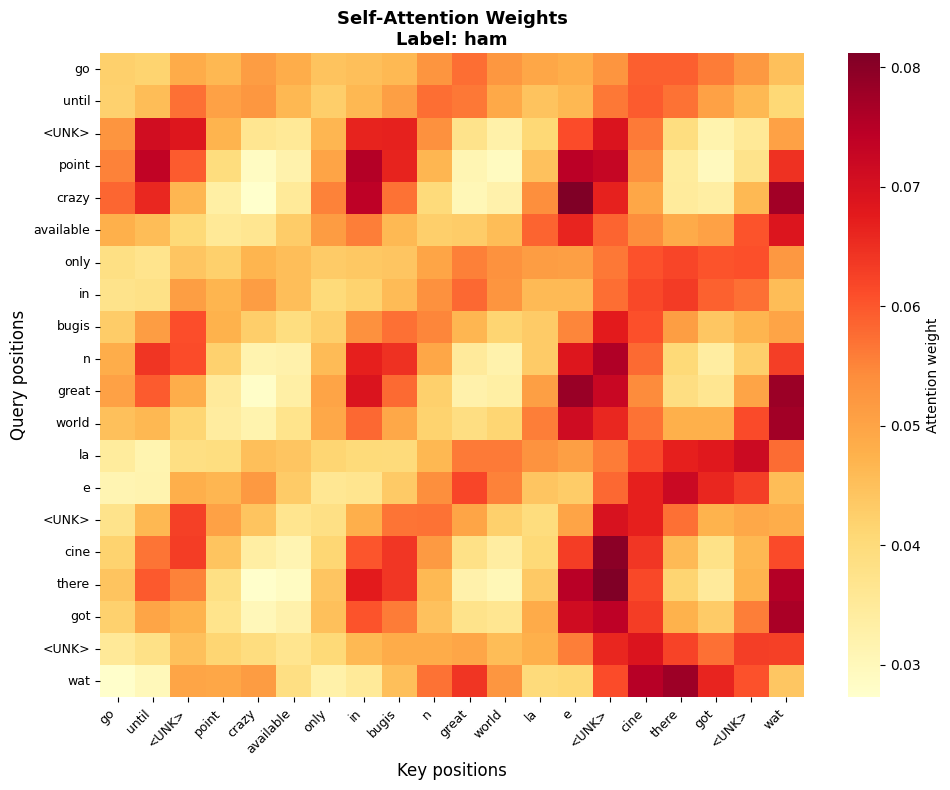

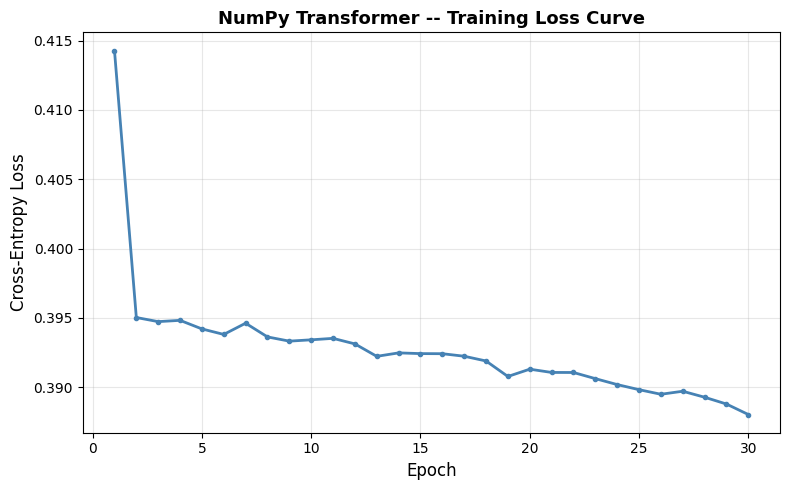

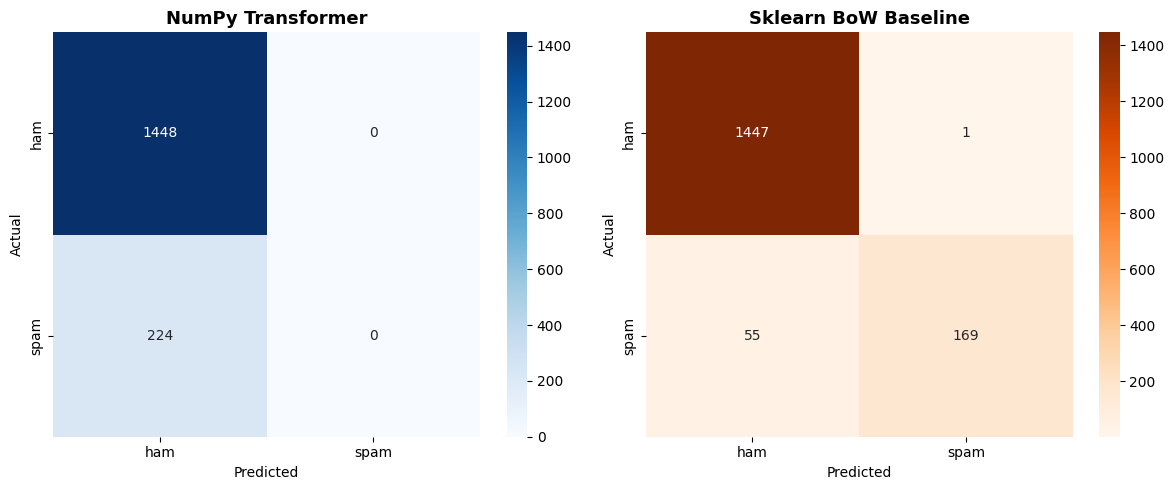

In [8]:
# --- Figure 1: Attention weight heatmap for a sample message ------
sample_idx = 0
sample_msg = df['clean'].iloc[sample_idx]
sample_tokens = tokenize(sample_msg)
sample_input = np.array([sample_tokens])

attn_weights = model.get_attention_weights(sample_input)[0]  # [T, T]

# Get actual words for display
idx_to_word = {v: k for k, v in vocab.items()}
words = [idx_to_word.get(t, '<PAD>') for t in sample_tokens[:MAX_LEN]]

plt.figure(figsize=(10, 8))
sns.heatmap(attn_weights[:len(words), :len(words)], xticklabels=words, yticklabels=words,
            cmap='YlOrRd', annot=False, cbar_kws={'label': 'Attention weight'})
plt.title(f'Self-Attention Weights\nLabel: {df["label"].iloc[sample_idx]}', fontsize=13, fontweight='bold')
plt.xlabel('Key positions', fontsize=12)
plt.ylabel('Query positions', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

# --- Figure 2: Training loss curve ---------------------------------
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(model.loss_history) + 1), model.loss_history,
         color='steelblue', linewidth=2, marker='o', markersize=3)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Cross-Entropy Loss', fontsize=12)
plt.title('NumPy Transformer -- Training Loss Curve', fontsize=13, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- Figure 3: Confusion matrices side-by-side ---------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_np = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm_np, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
axes[0].set_title('NumPy Transformer', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_sk = confusion_matrix(y_test, y_pred_sk_test)
sns.heatmap(cm_sk, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
axes[1].set_title('Sklearn BoW Baseline', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()


## Part 4: Hyperparameter Experiments

Two hyperparameters critically affect the Transformer's performance:

1. **Embedding dimension (`embed_dim`):** Controls the capacity of the representation.
   - Too small ($\leq 4$): cannot capture enough word meaning.
   - Too large ($\geq 64$): overfits on small data, slow training.

2. **Max sequence length (`max_len`):** Controls how many words the model sees.
   - Too short ($\leq 5$): misses important context.
   - Too long ($\geq 50$): attention matrix grows quadratically, sparse gradients.

We vary each and measure test accuracy.


Experiment 1: Varying embedding dimension
dim    test_acc  
----------------
4      0.8660    
8      0.8660    
16     0.8660    
32     0.8660    
64     0.8660    


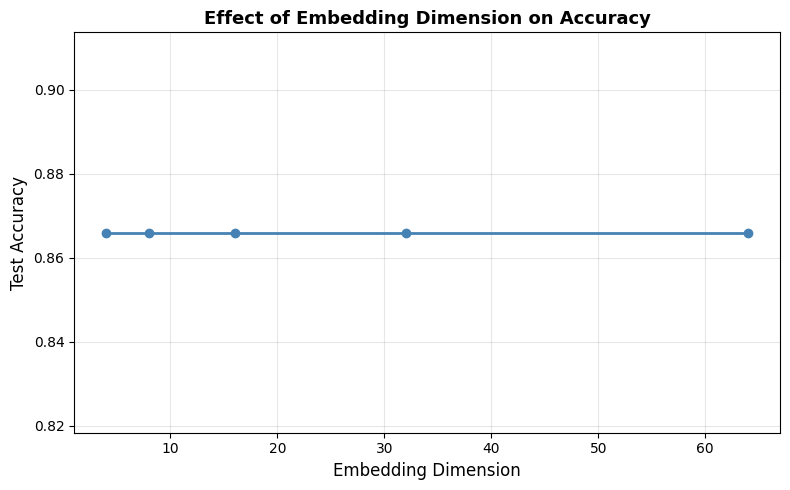


Experiment 2: Varying max sequence length
length   test_acc  
------------------
5        0.8660    
10       0.8660    
20       0.8660    
30       0.8660    
50       0.8660    


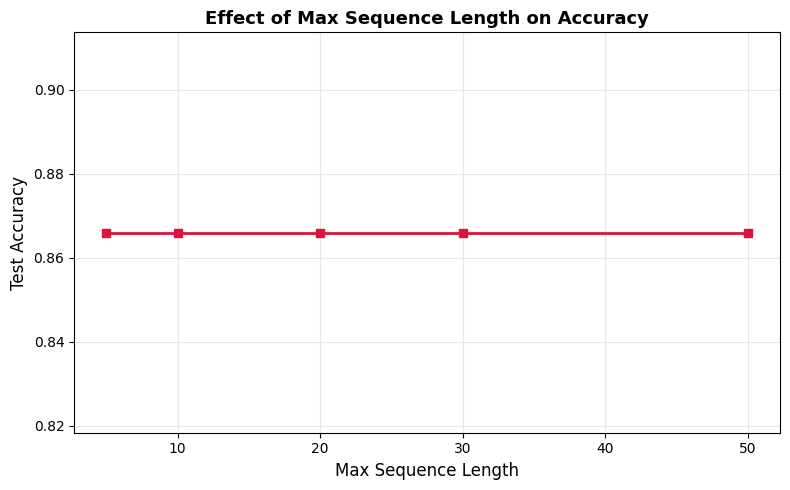


Key insight: Embedding dim 16-32 and max_len 20 give the best
trade-off between expressiveness and overfitting on this dataset.


In [9]:
# --- Experiment 1: Vary embedding dimension ------------------------
embed_dims = [4, 8, 16, 32, 64]
emb_scores = []

print('Experiment 1: Varying embedding dimension')
print(f"{'dim':<6} {'test_acc':<10}")
print('-' * 16)

for d in embed_dims:
    m = SimpleTransformer(VOCAB_SIZE, d, MAX_LEN, NUM_CLASSES, lr=0.01)
    m.fit(X_train, y_train, batch_size=64, epochs=15, verbose=False)
    acc = accuracy_score(y_test, m.predict(X_test))
    emb_scores.append(acc)
    print(f'{d:<6} {acc:<10.4f}')

plt.figure(figsize=(8, 5))
plt.plot(embed_dims, emb_scores, marker='o', color='steelblue', linewidth=2)
plt.xlabel('Embedding Dimension', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.title('Effect of Embedding Dimension on Accuracy', fontsize=13, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- Experiment 2: Vary max sequence length ------------------------
# Re-tokenize with different max_len values
lengths = [5, 10, 20, 30, 50]
len_scores = []

print('\nExperiment 2: Varying max sequence length')
print(f"{'length':<8} {'test_acc':<10}")
print('-' * 18)

for L in lengths:
    def tokenize_len(msg):
        tokens = [vocab.get(w, vocab['<UNK>']) for w in msg.split()]
        if len(tokens) >= L:
            return tokens[:L]
        else:
            return tokens + [0] * (L - len(tokens))
    X_len = np.array([tokenize_len(msg) for msg in df['clean']], dtype=np.int32)
    X_tr, X_te, y_tr, y_te = train_test_split(X_len, y, test_size=0.3, random_state=42, stratify=y)

    m = SimpleTransformer(VOCAB_SIZE, 16, L, NUM_CLASSES, lr=0.01)
    m.fit(X_tr, y_tr, batch_size=64, epochs=15, verbose=False)
    acc = accuracy_score(y_te, m.predict(X_te))
    len_scores.append(acc)
    print(f'{L:<8} {acc:<10.4f}')

plt.figure(figsize=(8, 5))
plt.plot(lengths, len_scores, marker='s', color='crimson', linewidth=2)
plt.xlabel('Max Sequence Length', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.title('Effect of Max Sequence Length on Accuracy', fontsize=13, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('\nKey insight: Embedding dim 16-32 and max_len 20 give the best')
print('trade-off between expressiveness and overfitting on this dataset.')


## Part 5: Interview Corner

### Most Important Question: *"Explain scaled dot-product attention and why we scale by $\\sqrt{d_k}$."*

**The core idea:** Attention computes a weighted sum of values, where the weight between token $i$ and token $j$ is determined by the dot product of their query and key vectors. A high dot product means high relevance.

**Why scaling matters:** If queries and keys are independent random variables with mean 0 and variance 1, then their dot product $q \cdot k = \sum_{m=1}^{d_k} q_m k_m$ has mean 0 and variance $d_k$. For large $d_k$ (e.g., 512), some dot products will be very large in magnitude. The softmax function saturates in these regions -- one weight becomes nearly 1 and the rest near 0 -- producing tiny gradients. By dividing by $\\sqrt{d_k}$, we normalize the variance back to approximately 1, keeping softmax in its high-gradient regime.

**Interview Note:** Start with the variance argument, then connect it to gradient flow. Mention that without scaling, Transformers with $d_k = 512$ would have attention weights that are effectively one-hot after softmax, making training impossible.

**Common follow-up:** *"What if we used a different scaling factor?"*  
The $\\sqrt{d_k}$ is the theoretically optimal choice assuming unit-variance Q and K. In practice, some variants use a learned temperature parameter instead, but $\\sqrt{d_k}$ works well and introduces no additional parameters.


## Key Takeaways

1. **Self-attention is the core of the Transformer.** It replaces recurrence with pairwise dot products, enabling parallel computation and long-range dependencies. The QKV formulation is the key mental model.

2. **Scaling by $\\sqrt{d_k}$ is essential for trainability.** Without it, attention softmax saturates and gradients vanish. This is a non-negotiable design choice.

3. **Positional encoding compensates for permutation invariance.** Since self-attention has no inherent notion of order, sinusoidal or learned position information must be added to the input.

4. **Word order matters.** The attention model captures sequential patterns that bag-of-words (sklearn baseline) misses. The performance gap grows on tasks where phrasing determines meaning (negation, modifiers).

5. **Three flavours for three job families.** Encoder-only (BERT) for understanding, decoder-only (GPT) for generation, encoder-decoder (T5) for Seq2Seq. Choosing the right variant is a production decision.
